In [1]:
# If you are running on Google Colab, UNCOMMENT this block.
'''
# ── Google Drive mount ────────────────────────────────────────────────────────
from google.colab import drive
drive.mount("/content/drive")
'''

Mounted at /content/drive


In [21]:
# =============================================================================
# IMPORTS, PATHS, CONSTANTS
# =============================================================================

from pathlib import Path
from collections import Counter
from typing import Dict, List, Tuple, Any

import json
import random
import time
import warnings

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.stats import mannwhitneyu
from tqdm import tqdm, trange

from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings("ignore")

if not hasattr(np, "bool8"):
    np.bool8 = np.bool_

# =============================================================================
# EXPERIMENT SETTINGS
# =============================================================================

MASTER_SEED = 42

# for faster run NUM_RUNS=1, EPISODE_BUDGET= 100. for paper results replication, set (NUM_RUNS=10, EPISODE_BUDGET= 1500)
NUM_RUNS = 10
EPISODE_BUDGET = 1500

BASE_SEED_START = 5000

EPSILON = 0.01

ENV_NAME = "FrozenLake-v1"

FL_MAP = "4x4"
FL_SLIPPERY = True

GRID_SIZE = 4

N_STATES = 16
N_ACTIONS = 4

MAX_STEPS = 300

random.seed(MASTER_SEED)
np.random.seed(MASTER_SEED)

# =============================================================================
# PATHS
# =============================================================================

ROOT = Path(
    "/content/drive/MyDrive/mbrl-testing-frameworks-empirical-study"
)

AGENT_PATH = ROOT / "agents" / "dynaq" / "frozenlake"

RESULTS_DIR = ROOT / "results" / "frozenlake"

RAW_DIR = RESULTS_DIR / "raw"
TABLES_DIR = RESULTS_DIR / "tables"
FIGS_DIR = RESULTS_DIR / "figs"

for p in [RESULTS_DIR, RAW_DIR, TABLES_DIR, FIGS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("Agent:", AGENT_PATH)
print("Results:", RESULTS_DIR)

Agent: /content/drive/MyDrive/mbrl-testing-frameworks-empirical-study/agents/dynaq/frozenlake
Results: /content/drive/MyDrive/mbrl-testing-frameworks-empirical-study/results/frozenlake


In [22]:
# =============================================================================
# LOAD AGENT
# =============================================================================

Q = np.load(
    AGENT_PATH / "dynaq_Q_frozenlake.npy"
)

assert Q.shape == (
    N_STATES,
    N_ACTIONS,
)

cfg_file = (
    AGENT_PATH
    / "dynaq_config.json"
)

AGENT_CFG = (
    json.load(open(cfg_file))
    if cfg_file.exists()
    else {}
)

print("Q-table shape:", Q.shape)

# =============================================================================
# STATE UTILITIES
# =============================================================================

def fl_decode(state):

    return divmod(
        int(state),
        GRID_SIZE,
    )


def fl_encode(row, col):

    return (
        int(row) * GRID_SIZE
        + int(col)
    )


def fl_random_state(rng):

    return int(
        rng.integers(
            0,
            N_STATES,
        )
    )


def fl_manhattan(a, b):

    ra, ca = fl_decode(a)
    rb, cb = fl_decode(b)

    return (
        abs(ra - rb)
        + abs(ca - cb)
    )


_env_tmp = gym.make(
    ENV_NAME,
    map_name=FL_MAP,
    is_slippery=FL_SLIPPERY,
)

desc = np.array(
    _env_tmp.unwrapped.desc,
    dtype="U1",
)

_env_tmp.close()

FL_GOAL = next(
    fl_encode(r, c)
    for r in range(GRID_SIZE)
    for c in range(GRID_SIZE)
    if desc[r, c] == "G"
)

FL_HOLES = [
    fl_encode(r, c)
    for r in range(GRID_SIZE)
    for c in range(GRID_SIZE)
    if desc[r, c] == "H"
]

Q-table shape: (16, 4)


In [23]:
# =============================================================================
# EPISODE EXECUTION
# =============================================================================

def run_episode(
    initial_state,
    seed,
    epsilon=EPSILON,
):

    env = gym.make(
        ENV_NAME,
        map_name=FL_MAP,
        is_slippery=FL_SLIPPERY,
    )

    env.reset(seed=int(seed))

    env.unwrapped.s = int(
        initial_state
    )

    state = int(initial_state)

    rng = np.random.default_rng(seed)

    done = False
    reward = 0.0
    total_reward = 0.0
    steps = 0

    t0 = time.perf_counter()

    while (
        not done
        and steps < MAX_STEPS
    ):

        if rng.random() < epsilon:

            action = int(
                rng.integers(
                    0,
                    N_ACTIONS,
                )
            )

        else:

            action = int(
                np.argmax(Q[state])
            )

        next_state, reward, terminated, truncated, _ = env.step(action)

        done = terminated or truncated

        total_reward += float(reward)

        state = int(next_state)

        steps += 1

    elapsed = time.perf_counter() - t0

    env.close()

    failure = not (
        done
        and reward == 1
    )

    return {
        "return": float(total_reward),
        "failure": int(failure),
        "steps": int(steps),
        "time": float(elapsed),
    }


# =============================================================================
# METRICS
# =============================================================================

def compute_metrics(df, tcp_time=0.0):

    failures = df["failure"].values.astype(int)
    times = df["time"].values.astype(float)

    n = len(failures)

    total_failures = int(np.sum(failures))

    FR = total_failures / n

    if total_failures > 0:

        first_idx = np.where(
            failures == 1
        )[0][0]

        TTF_tests = first_idx + 1

        TTF_time = np.sum(
            times[: first_idx + 1]
        )

    else:

        TTF_tests = np.nan
        TTF_time = np.nan

    if total_failures > 0:

        positions = (
            np.where(failures == 1)[0]
            + 1
        )

        APFD = (
            1
            - np.sum(positions)
            / (n * total_failures)
            + 1 / (2 * n)
        )

    else:

        APFD = np.nan

    if total_failures > 0:

        cumulative_time = np.cumsum(times)

        fail_times = cumulative_time[
            np.where(failures == 1)[0]
        ]

        total_time = cumulative_time[-1]

        APFD_time = (
            1
            - np.sum(fail_times)
            / (total_time * total_failures)
            + 1 / (2 * total_time)
        )

    else:

        APFD_time = np.nan

    return {
        "FR": float(FR),
        "TTF_tests": float(TTF_tests),
        "TTF_time": float(TTF_time),
        "APFD": float(APFD),
        "APFD_time": float(APFD_time),
        "TCP_time": float(tcp_time),
        "Per_test_overhead": float(
            tcp_time / n
        ),
    }

In [24]:
# =============================================================================
# TCP SIGNALS
# =============================================================================

def softmax(q, tau=1.0):

    q = q / tau

    q = q - np.max(q)

    e = np.exp(q)

    return e / np.sum(e)


def annotate_pool_returns(pool):

    annotated = []

    for t in pool:

        res = run_episode(
            initial_state=int(
                t["initial_state"]
            ),
            seed=int(
                t["seed"]
            ),
            epsilon=0.0,
        )

        annotated.append({
            **t,
            "return": float(
                res["return"]
            ),
        })

    return annotated


def tcp_fifo(pool, **_):
    return sorted(pool, key=lambda x: x["episode_id"])


def tcp_random(pool, seed=MASTER_SEED, **_):

    rng = np.random.default_rng(seed)

    shuffled = pool.copy()

    rng.shuffle(shuffled)

    return shuffled


def tcp_entropy(pool, Q, **_):

    scored = []

    for t in pool:

        probs = softmax(
            Q[int(t["initial_state"])]
        )

        entropy = float(
            -np.sum(
                probs * np.log(
                    probs + 1e-12
                )
            )
        )

        scored.append({
            **t,
            "score": entropy,
        })

    return sorted(
        scored,
        key=lambda x: x["score"],
        reverse=True,
    )


def tcp_margin(pool, Q, **_):

    scored = []

    for t in pool:

        q_sorted = np.sort(
            Q[int(t["initial_state"])]
        )[::-1]

        margin = float(
            q_sorted[0] - q_sorted[1]
        )

        scored.append({
            **t,
            "score": margin,
        })

    return sorted(
        scored,
        key=lambda x: x["score"],
    )


def tcp_confidence(pool, Q, **_):

    scored = []

    for t in pool:

        probs = softmax(
            Q[int(t["initial_state"])]
        )

        confidence = float(
            np.max(probs)
        )

        scored.append({
            **t,
            "score": confidence,
        })

    return sorted(
        scored,
        key=lambda x: x["score"],
    )


def tcp_value_return_gap(pool, Q, **_):

    pool = annotate_pool_returns(pool)

    scored = []

    for t in pool:

        s = int(t["initial_state"])

        predicted = float(
            np.max(Q[s])
        )

        observed = float(
            t["return"]
        )

        gap = abs(
            predicted - observed
        )

        scored.append({
            **t,
            "score": gap,
        })

    return sorted(
        scored,
        key=lambda x: x["score"],
        reverse=True,
    )


def tcp_q_variance(pool, Q, **_):

    scored = []

    for t in pool:

        variance = float(
            np.var(
                Q[int(t["initial_state"])]
            )
        )

        scored.append({
            **t,
            "score": variance,
        })

    return sorted(
        scored,
        key=lambda x: x["score"],
        reverse=True,
    )


def tcp_state_novelty(pool, **_):

    counts = Counter(
        int(t["initial_state"])
        for t in pool
    )

    scored = []

    for t in pool:

        novelty = (
            1.0 /
            counts[
                int(t["initial_state"])
            ]
        )

        scored.append({
            **t,
            "score": novelty,
        })

    return sorted(
        scored,
        key=lambda x: x["score"],
        reverse=True,
    )


TCP_REGISTRY = {
    "FIFO": tcp_fifo,
    "Random": tcp_random,
    "Entropy": tcp_entropy,
    "Margin": tcp_margin,
    "Confidence": tcp_confidence,
    "ValueReturnGap": tcp_value_return_gap,
    "QVariance": tcp_q_variance,
    "StateNovelty": tcp_state_novelty,
}

In [25]:
# =============================================================================
# PHASE 1 — TCP ONLY
# =============================================================================

def generate_random_pool(
    base_seed,
    budget=EPISODE_BUDGET,
):

    rng = np.random.default_rng(base_seed)

    pool = []

    for episode_id in range(budget):

        seed = int(base_seed + episode_id)

        state = fl_random_state(rng)

        result = run_episode(
            initial_state=state,
            seed=seed,
            epsilon=EPSILON,
        )

        pool.append({
            "episode_id": episode_id,
            "seed": seed,
            "initial_state": int(state),

            "return": float(result["return"]),
            "failure": int(result["failure"]),
            "steps": int(result["steps"]),
            "time": float(result["time"]),
        })

    return pool


def apply_tcp(
    pool,
    tcp_name,
    run_seed,
):

    func = TCP_REGISTRY[tcp_name]

    start = time.perf_counter()

    if tcp_name == "FIFO":

        ordered_pool = func(pool)

    elif tcp_name == "Random":

        ordered_pool = func(
            pool,
            seed=run_seed,
        )

    else:

        ordered_pool = func(
            pool,
            Q=Q,
        )

    tcp_time = time.perf_counter() - start

    return ordered_pool, tcp_time


def evaluate_phase1_pool(
    ordered_pool,
    tcp_time,
):

    df = pd.DataFrame({
        "failure": [
            t["failure"]
            for t in ordered_pool
        ],
        "time": [
            t["time"]
            for t in ordered_pool
        ],
    })

    metrics = compute_metrics(
        df,
        tcp_time=tcp_time,
    )

    return metrics


def run_phase1_single_run(
    run_id,
    base_seed,
):

    print(
        f"\nPhase 1 | Run {run_id + 1} "
        f"(seed={base_seed})"
    )

    pool = generate_random_pool(
        base_seed=base_seed,
        budget=EPISODE_BUDGET,
    )

    rows = []

    for tcp_name in TCP_REGISTRY:

        ordered_pool, tcp_time = apply_tcp(
            pool,
            tcp_name,
            base_seed,
        )

        metrics = evaluate_phase1_pool(
            ordered_pool,
            tcp_time,
        )

        row = {
            "run_id": run_id,
            "TCP": tcp_name,
        }

        row.update(metrics)

        rows.append(row)

        print(
            f"{tcp_name:<18}"
            f"APFD={metrics['APFD']:.4f}"
        )

    return rows


def run_phase1(
    num_runs=NUM_RUNS,
):

    all_rows = []

    for run_id in range(num_runs):

        base_seed = (
            BASE_SEED_START
            + run_id * 10000
        )

        rows = run_phase1_single_run(
            run_id,
            base_seed,
        )

        all_rows.extend(rows)

    results = pd.DataFrame(all_rows)

    results.to_csv(
        TABLES_DIR / "phase1_results.csv",
        index=False,
    )

    return results


def summarize_phase1(results):

    metrics = [
        "FR",
        "TTF_tests",
        "TTF_time",
        "APFD",
        "APFD_time",
        "TCP_time",
        "Per_test_overhead",
    ]

    agg = (
        results
        .groupby("TCP")[metrics]
        .agg(["mean", "std"])
        .round(6)
    )

    agg.columns = [
        "_".join(col)
        for col in agg.columns
    ]

    agg = agg.reset_index()

    agg.to_csv(
        TABLES_DIR / "phase1_aggregate.csv",
        index=False,
    )

    return agg

In [26]:
def evaluate_ordered_pool(
    ordered_pool,
    tcp_time,
):

    rows = []

    for test in ordered_pool:

        result = run_episode(
            initial_state=int(
                test["initial_state"]
            ),
            seed=int(
                test["seed"]
            ),
            epsilon=EPSILON,
        )

        rows.append({
            "initial_state": int(
                test["initial_state"]
            ),
            "return": float(
                result["return"]
            ),
            "failure": int(
                result["failure"]
            ),
            "steps": int(
                result["steps"]
            ),
            "time": float(
                result["time"]
            ),
        })

    df = pd.DataFrame(rows)

    metrics = compute_metrics(
        df,
        tcp_time=tcp_time,
    )

    return df, metrics
# ==============================================================================
#  FRAMEWORK: INDAGO
# ==============================================================================
#
# Literature (Perez et al.):
#   Large candidate pool → label subset by execution → train RandomForest →
#   rank all candidates by predicted failure probability → keep top-K.
def _indago_features_fl(state: int) -> List[float]:
    row, col = fl_decode(state)

    dist_goal = fl_manhattan(state, FL_GOAL)
    dist_hole = min((fl_manhattan(state, h) for h in FL_HOLES), default=0)

    q_row = Q[state]
    q_max = float(np.max(q_row))
    q_var = float(np.var(q_row))

    q_sorted = np.sort(q_row)[::-1]
    q_gap = float(q_sorted[0] - q_sorted[1]) if N_ACTIONS >= 2 else 0.0

    probs = softmax(q_row)
    entropy = float(-np.sum(probs * np.log(probs + 1e-12)))

    on_hole = float(state in FL_HOLES)
    near_hole = float(dist_hole <= 1)
    is_goal = float(state == FL_GOAL)

    return [
        float(row),
        float(col),
        float(dist_goal),
        float(dist_hole),
        q_max,
        q_var,
        q_gap,
        entropy,
        on_hole,
        near_hole,
        is_goal,
    ]


def generate_tests_indago(
    base_seed: int,
    budget: int = EPISODE_BUDGET,
    pool_size: int = 3000,
    train_size: int = 600,
) -> List[Dict]:

    rng = np.random.default_rng(base_seed)

    pool = []
    for i in range(pool_size):
        seed = int(base_seed + i)
        s = fl_random_state(np.random.default_rng(seed))

        pool.append({
            "episode_id": i,
            "seed": seed,
            "initial_state": int(s),
        })

    train_size = min(train_size, pool_size)
    label_idx = rng.choice(pool_size, size=train_size, replace=False)

    X_train = []
    y_train = []
    label_info = {}

    for idx in label_idx:
        idx = int(idx)
        t = pool[idx]
        s = int(t["initial_state"])

        res = run_episode(
            initial_state=s,
            seed=int(t["seed"]),
            epsilon=0.0,
        )

        X_train.append(_indago_features_fl(s))
        y_train.append(int(res["failure"]))

        label_info[idx] = {
            "return": float(res["return"]),
            "failure": int(res["failure"]),
            "steps": int(res["steps"]),
        }

    y_train = np.array(y_train)

    if len(np.unique(y_train)) < 2:
        scores = []
        for t in pool:
            s = int(t["initial_state"])
            feats = _indago_features_fl(s)
            heuristic = feats[7] + feats[5] + feats[9] + feats[8] + 0.1 * feats[2]
            scores.append(float(heuristic))
    else:
        clf = RandomForestClassifier(
            n_estimators=200,
            random_state=base_seed,
            class_weight="balanced",
            n_jobs=-1,
        )

        clf.fit(np.array(X_train), y_train)

        X_all = np.array([
            _indago_features_fl(int(t["initial_state"]))
            for t in pool
        ])

        scores = clf.predict_proba(X_all)[:, 1]

    scores = np.array(scores)
    top_k = int(0.70 * budget)

    top_idx = np.argsort(-scores)[:top_k]

    remaining = [i for i in range(len(pool)) if i not in set(top_idx)]
    rng.shuffle(remaining)

    sel_idx = np.concatenate([
        top_idx,
        remaining[:budget - top_k]
    ])

    test_pool = []
    for rank, idx in enumerate(sel_idx):
        idx = int(idx)
        t = pool[idx].copy()
        t["episode_id"] = rank
        t["indago_score"] = float(scores[idx])

        if idx in label_info:
            t.update(label_info[idx])

        test_pool.append(t)

    return test_pool

# ==============================================================================
# FRAMEWORK: STARLA
# ==============================================================================
#
# Literature (Acharya et al.):
#   Genetic-algorithm search over initial states guided by a risk proxy.
#   Fitness = 10 × failure + risk_proxy(state) − 0.1 × return.
#   Selection: top-50% by fitness become parents.
#   Offspring: mutated parent states.
def _fl_risk_proxy(state: int) -> float:
    q_row = Q[int(state)]

    q_sorted = np.sort(q_row)[::-1]
    q_gap = float(q_sorted[0] - q_sorted[1]) if N_ACTIONS >= 2 else 0.0

    probs = softmax(q_row)
    entropy = float(-np.sum(probs * np.log(probs + 1e-12)))

    dist_goal = fl_manhattan(state, FL_GOAL)
    dist_hole = min((fl_manhattan(state, h) for h in FL_HOLES), default=0)

    on_hole = float(state in FL_HOLES)
    near_hole = float(dist_hole <= 1)

    return float(
        entropy
        + 1.0 / (q_gap + 1e-6)
        + 0.25 * dist_goal
        + 2.0 / (dist_hole + 1)
        + 3.0 * on_hole
        + 1.0 * near_hole
    )


def _fl_mutate_state(state: int, rng: np.random.Generator) -> int:
    row, col = fl_decode(state)

    dr = int(rng.choice([-1, 0, 1]))
    dc = int(rng.choice([-1, 0, 1]))

    row = int(np.clip(row + dr, 0, GRID_SIZE - 1))
    col = int(np.clip(col + dc, 0, GRID_SIZE - 1))

    return fl_encode(row, col)


def _fl_eval_state_fast(state: int, seed: int) -> Tuple[float, int, int]:
    res = run_episode(
        initial_state=state,
        seed=seed,
        epsilon=0.0,
    )
    return float(res["return"]), int(res["steps"]), int(res["failure"])


def generate_tests_starla(
    base_seed: int,
    budget: int = EPISODE_BUDGET,
    pop_size: int = 100,
    elite_frac: float = 0.5,
) -> List[Dict]:
    rng = np.random.default_rng(base_seed)
    gens = int(np.ceil(budget / pop_size))

    pop = [fl_random_state(rng) for _ in range(pop_size)]
    pool = []

    for _gen in trange(gens, desc="STARLA: evolving", leave=False):
        scored = []

        for state in pop:
            if len(pool) >= budget:
                break

            seed_ep = int(base_seed + len(pool))
            ret, steps, fail = _fl_eval_state_fast(state, seed_ep)

            fitness = (
                100.0 * fail
                + float(steps)
                + abs(float(ret))
                + _fl_risk_proxy(state)
            )

            pool.append({
                "episode_id": len(pool),
                "seed": seed_ep,
                "initial_state": int(state),
                "return": float(ret),
                "failure": int(fail),
                "steps": int(steps),
                "starla_fitness": float(fitness),
            })

            scored.append((fitness, int(state)))

        if len(pool) >= budget:
            break

        scored.sort(key=lambda x: x[0], reverse=True)

        n_elite = max(1, int(pop_size * elite_frac))
        parents = [s for _, s in scored[:n_elite]]

        offspring = []
        while len(offspring) < pop_size - n_elite:
            parent = int(rng.choice(parents))
            offspring.append(_fl_mutate_state(parent, rng))

        pop = parents + offspring

    return pool[:budget]

# ==============================================================================
# FRAMEWORK: QD-TESTING
# ==============================================================================
#
# Literature (Castellano et al.):
#   Quality-Diversity archive: cell = BD(state).
#   BD for FrozenLake: (dist_to_goal, dist_to_nearest_hole) — discretised.
#   Fitness: lexicographic (failure_flag, −steps).
def _fl_bd(state: int) -> Tuple[int, int, int]:

    row, col = fl_decode(state)

    dist_goal = fl_manhattan(state, FL_GOAL)
    dist_hole = min((fl_manhattan(state, h) for h in FL_HOLES), default=0)

    goal_bin = min(4, dist_goal)
    hole_bin = min(4, dist_hole)

    # 4x4 map: split into four 2x2 regions.
    region = (0 if row < GRID_SIZE // 2 else 1) * 2 + (0 if col < GRID_SIZE // 2 else 1)

    return (int(goal_bin), int(hole_bin), int(region))


def _fl_bd_cell(bd: Tuple[int, int, int]) -> Tuple[int, int, int]:
    return bd


def generate_tests_qd(
    base_seed: int,
    budget: int = EPISODE_BUDGET,
    init_seeds: int = 200,
) -> List[Dict]:
    rng = np.random.default_rng(base_seed)
    archive = {}
    pool = []

    def _qd_quality(fail: int, steps: int, ret: float) -> Tuple[int, int, float]:
        # Failure first, then longer/harder episode, then lower return.
        return (int(fail), int(steps), float(-ret))

    def _try_add(state: int, seed: int):
        ret, steps, fail = _fl_eval_state_fast(state, seed)
        cell = _fl_bd_cell(_fl_bd(state))
        quality = _qd_quality(fail, steps, ret)

        if cell not in archive or quality > archive[cell]["quality"]:
            archive[cell] = {
                "state": int(state),
                "seed": int(seed),
                "quality": quality,
            }

        pool.append({
            "episode_id": len(pool),
            "seed": int(seed),
            "initial_state": int(state),
            "return": float(ret),
            "failure": int(fail),
            "steps": int(steps),
            "qd_cell": str(cell),
            "qd_quality": str(quality),
        })

    for i in trange(init_seeds, desc="QD-Testing: init", leave=False):
        if len(pool) >= budget:
            break

        state = fl_random_state(rng)
        _try_add(state, int(base_seed + i))

    while len(pool) < budget:
        if archive:
            elite = rng.choice(list(archive.values()))
            state = _fl_mutate_state(int(elite["state"]), rng)
        else:
            state = fl_random_state(rng)

        seed_ep = int(base_seed + len(pool))
        _try_add(state, seed_ep)

    return pool[:budget]

# ==============================================================================
# FRAMEWORK: RLMUTATION
# ==============================================================================
#
# Literature (Tappler et al.):
#   Apply environment mutants; collect episodes.
#   Oracle: clean environment (evaluate_ordered_pool uses run_episode).
#
# Four mutant operators (each gets budget // 4 episodes):
#   RN  — Gaussian noise added to the reward signal on positive rewards
#   M   — Mangled observations (random past-step replayed with prob p)
#   R   — Repeated observation (previous step replayed with prob p)
#   RA  — Random action injection (replace greedy with random with prob p)
#         (replaces Taxi's worst-action, which collapses results in stochastic envs)

class RewardNoiseMutant(gym.Wrapper):
    def __init__(self, env, sigma=0.20):
        super().__init__(env)
        self.sigma = sigma

    def step(self, action):
        ns, r, term, trunc, info = self.env.step(action)

        if term and r > 0:
            r = float(r + np.random.normal(0.0, self.sigma))

        return ns, r, term, trunc, info


class RandomActionMutant(gym.Wrapper):
    def __init__(self, env, p=0.15):
        super().__init__(env)
        self.p = p

    def step(self, action):
        if np.random.rand() < self.p:
            action = int(np.random.randint(0, N_ACTIONS))

        return self.env.step(action)


class ObservationRepeatMutant(gym.Wrapper):
    def __init__(self, env, p=0.20):
        super().__init__(env)
        self.p = p
        self.prev = None

    def reset(self, **kwargs):
        self.prev = None
        return self.env.reset(**kwargs)

    def step(self, action):
        out = self.env.step(action)

        if self.prev is not None and np.random.rand() < self.p:
            returned = self.prev
        else:
            returned = out

        self.prev = out
        return returned


class ObservationMangleMutant(gym.Wrapper):
    def __init__(self, env, p=0.20):
        super().__init__(env)
        self.p = p
        self.buf = []

    def reset(self, **kwargs):
        self.buf.clear()
        return self.env.reset(**kwargs)

    def step(self, action):
        out = self.env.step(action)
        self.buf.append(out)

        if self.buf and np.random.rand() < self.p:
            return random.choice(self.buf)

        return out


def _make_rlmutation_env_fl(tag: str):
    base = gym.make(ENV_NAME, map_name=FL_MAP, is_slippery=FL_SLIPPERY)

    if tag == "RewardNoise":
        return RewardNoiseMutant(base, sigma=0.20)

    if tag == "RandomAction":
        return RandomActionMutant(base, p=0.15)

    if tag == "ObservationRepeat":
        return ObservationRepeatMutant(base, p=0.20)

    if tag == "ObservationMangle":
        return ObservationMangleMutant(base, p=0.20)

    return base


def _run_episode_mutant_fl(env, Q, initial_state, seed, epsilon=0.0):
    env.reset(seed=int(seed))
    env.unwrapped.s = int(initial_state)

    rng = np.random.default_rng(int(seed))
    state = int(initial_state)
    done = False
    steps = 0
    total_reward = 0.0
    reward = 0.0

    t0 = time.perf_counter()

    while not done and steps < MAX_STEPS:
        if rng.random() < epsilon:
            action = int(rng.integers(0, N_ACTIONS))
        else:
            action = int(np.argmax(Q[state]))

        ns, reward, term, trunc, _ = env.step(action)

        done = term or trunc
        total_reward += float(reward)
        state = int(ns)
        steps += 1

    return {
        "return": float(total_reward),
        "failure": int(not (done and reward == 1)),
        "steps": int(steps),
        "time": float(time.perf_counter() - t0),
    }


def generate_tests_rlmutation(
    base_seed: int,
    budget: int = EPISODE_BUDGET,
) -> List[Dict]:

    mutant_tags = [
        "RewardNoise",
        "RandomAction",
        "ObservationRepeat",
        "ObservationMangle",
    ]

    share = int(np.ceil(budget / len(mutant_tags)))
    pool = []

    for k, tag in enumerate(mutant_tags):
        for i in tqdm(range(share), desc=f"RLMutation [{tag}]", leave=False):
            if len(pool) >= budget:
                break

            seed_ep = int(base_seed + k * share + i)
            state = fl_random_state(np.random.default_rng(seed_ep))

            env_m = _make_rlmutation_env_fl(tag)
            res = _run_episode_mutant_fl(env_m, Q, state, seed_ep, epsilon=0.0)
            env_m.close()

            pool.append({
                "episode_id": len(pool),
                "seed": seed_ep,
                "initial_state": int(state),
                "mutant": tag,
                "return": float(res["return"]),
                "failure": int(res["failure"]),
                "steps": int(res["steps"]),
                "mutant_failure": int(res["failure"]),
            })

    return pool[:budget]


def evaluate_ordered_pool_rlmutation(
    ordered_pool: List[Dict],
    Q: np.ndarray,
    tcp_time: float,
) -> Tuple[pd.DataFrame, Dict]:

    rows = []

    for test in ordered_pool:
        state = int(test["initial_state"])
        seed = int(test["seed"])
        tag = test.get("mutant", "NONE")

        env_m = _make_rlmutation_env_fl(tag)
        result = _run_episode_mutant_fl(env_m, Q, state, seed, epsilon=0.0)
        env_m.close()

        rows.append({
            "initial_state": state,
            "mutant": tag,
            "return": float(result["return"]),
            "failure": int(result["failure"]),
            "steps": int(result["steps"]),
            "time": float(result["time"]),
        })

    df = pd.DataFrame(rows)
    metrics = compute_metrics(df, tcp_time=tcp_time)
    return df, metrics
# ==============================================================================
# FRAMEWORK: MDPFUZZ
# ==============================================================================
#
# Literature (Qi et al.):
#   Coverage-guided fuzzing.  Corpus = failure-producing states.
#   Coverage = unique BD cells.
#   Mutation = grid-based perturbation of (row, col).
def _run_episode_trace_fl(Q, initial_state, seed, epsilon=0.0, max_steps=MAX_STEPS):
    env = gym.make(ENV_NAME, map_name=FL_MAP, is_slippery=FL_SLIPPERY)
    env.reset(seed=int(seed))
    env.unwrapped.s = int(initial_state)

    rng = np.random.default_rng(int(seed))
    state = int(initial_state)

    visited = [state]
    done = False
    steps = 0
    total_reward = 0.0
    reward = 0.0

    t0 = time.perf_counter()

    while not done and steps < max_steps:
        if rng.random() < epsilon:
            action = int(rng.integers(0, N_ACTIONS))
        else:
            action = int(np.argmax(Q[state]))

        ns, reward, term, trunc, _ = env.step(action)

        done = term or trunc
        total_reward += float(reward)
        state = int(ns)
        visited.append(state)
        steps += 1

    env.close()

    return {
        "return": float(total_reward),
        "failure": int(not (done and reward == 1)),
        "steps": int(steps),
        "time": float(time.perf_counter() - t0),
        "visited": visited,
    }


def _mdpfuzz_coverage_cells_fl(visited_states):
    cells = set()

    for s in visited_states:
        row, col = fl_decode(int(s))

        dist_goal = fl_manhattan(s, FL_GOAL)
        dist_hole = min((fl_manhattan(s, h) for h in FL_HOLES), default=0)

        cell = (
            int(row),
            int(col),
            int(min(4, dist_goal)),
            int(min(4, dist_hole)),
        )

        cells.add(cell)

    return cells


def generate_tests_mdpfuzz(
    base_seed: int,
    budget: int = EPISODE_BUDGET,
    init_size: int = 300,
) -> List[Dict]:

    rng = np.random.default_rng(base_seed)

    corpus = []
    global_coverage = set()
    pool = []

    for i in trange(init_size, desc="MDPFuzz: init corpus", leave=False):
        if len(pool) >= budget:
            break

        seed_ep = int(base_seed + i)
        state = fl_random_state(rng)

        res = _run_episode_trace_fl(Q, state, seed_ep, epsilon=0.0)
        cells = _mdpfuzz_coverage_cells_fl(res["visited"])
        new_cells = cells - global_coverage

        if res["failure"] or new_cells:
            corpus.append(int(state))
            global_coverage |= cells

        pool.append({
            "episode_id": len(pool),
            "seed": seed_ep,
            "initial_state": int(state),
            "return": float(res["return"]),
            "failure": int(res["failure"]),
            "steps": int(res["steps"]),
            "coverage_gain": int(len(new_cells)),
        })

    if not corpus:
        corpus = [p["initial_state"] for p in pool[:min(50, len(pool))]]

    while len(pool) < budget:
        parent = int(rng.choice(corpus))
        state = _fl_mutate_state(parent, rng)
        seed_ep = int(base_seed + len(pool))

        res = _run_episode_trace_fl(Q, state, seed_ep, epsilon=0.0)
        cells = _mdpfuzz_coverage_cells_fl(res["visited"])
        new_cells = cells - global_coverage

        if res["failure"] or new_cells:
            corpus.append(int(state))
            global_coverage |= cells

        pool.append({
            "episode_id": len(pool),
            "seed": seed_ep,
            "initial_state": int(state),
            "return": float(res["return"]),
            "failure": int(res["failure"]),
            "steps": int(res["steps"]),
            "coverage_gain": int(len(new_cells)),
        })

    return pool[:budget]
# ==============================================================================
# FRAMEWORK: NR-RL
# ==============================================================================
#
# Literature (Nakamura et al.):
#   Natural Robustness testing — execute the greedy policy under mild
#   action perturbation to expose stochasticity-sensitive failures.
#
# Q4 resolution for FrozenLake:
#   • FrozenLake with is_slippery=True is already stochastic.
#   • Worst-action injection would collapse results.
#   • Perturbation: with probability NR_RL_P_RAND, select a random action;
#     otherwise greedy.  This is the mild form confirmed in Q4.
#   • TCP ranks by clean Q-table signals on the initial state (no perturbation
#     at ranking time).
NR_RL_P_RAND = 0.05


def generate_tests_nrrl(base_seed: int, budget: int = EPISODE_BUDGET) -> List[Dict]:
    pool = []

    for i in range(budget):
        seed = int(base_seed + i)
        state = fl_random_state(np.random.default_rng(seed))

        pool.append({
            "episode_id": i,
            "seed": seed,
            "initial_state": int(state),
        })

    return pool


def run_episode_nrrl_fl(
    Q: np.ndarray,
    initial_state: int,
    seed: int,
    p_rand: float = NR_RL_P_RAND,
    max_steps: int = MAX_STEPS,
) -> Dict:

    env = gym.make(ENV_NAME, map_name=FL_MAP, is_slippery=FL_SLIPPERY)
    env.reset(seed=int(seed))
    env.unwrapped.s = int(initial_state)

    rng = np.random.default_rng(int(seed))
    state = int(initial_state)

    done = False
    steps = 0
    total_reward = 0.0
    reward = 0.0

    t0 = time.perf_counter()

    while not done and steps < max_steps:
        if rng.random() < p_rand:
            action = int(rng.integers(0, N_ACTIONS))
        else:
            action = int(np.argmax(Q[state]))

        ns, reward, term, trunc, _ = env.step(action)

        done = term or trunc
        total_reward += float(reward)
        state = int(ns)
        steps += 1

    env.close()

    return {
        "return": float(total_reward),
        "failure": int(not (done and reward == 1)),
        "steps": int(steps),
        "time": float(time.perf_counter() - t0),
    }


def evaluate_ordered_pool_nrrl(
    ordered_pool: List[Dict],
    Q: np.ndarray,
    tcp_time: float,
) -> Tuple[pd.DataFrame, Dict]:

    rows = []

    for test in ordered_pool:
        result = run_episode_nrrl_fl(
            Q,
            initial_state=int(test["initial_state"]),
            seed=int(test["seed"]),
            p_rand=NR_RL_P_RAND,
        )
        rows.append({
            "initial_state": int(test["initial_state"]),
            "return": float(result["return"]),
            "failure": int(result["failure"]),
            "steps": int(result["steps"]),
            "time": float(result["time"]),
        })

    df = pd.DataFrame(rows)
    metrics = compute_metrics(df, tcp_time=tcp_time)
    return df, metrics
# ==============================================================================
# FRAMEWORK REGISTRY
# ==============================================================================

FRAMEWORK_REGISTRY: Dict[str, Dict] = {
    "Indago"     : {"gen": generate_tests_indago,      "eval": evaluate_ordered_pool},
    "STARLA"     : {"gen": generate_tests_starla,      "eval": evaluate_ordered_pool},
    "QD-Testing" : {"gen": generate_tests_qd,          "eval": evaluate_ordered_pool},
    "RLMutation" : {"gen": generate_tests_rlmutation,  "eval": evaluate_ordered_pool_rlmutation},
    "MDPFuzz"    : {"gen": generate_tests_mdpfuzz,     "eval": evaluate_ordered_pool},
    "NR-RL"      : {"gen": generate_tests_nrrl,        "eval": evaluate_ordered_pool_nrrl},
}

In [27]:
# =============================================================================
# PHASE 2 — FRAMEWORK-INTEGRATED TCP
# =============================================================================

def run_phase2_single_run(
    run_id,
    base_seed,
):

    print(
        f"\nPhase 2 | Run {run_id + 1} "
        f"(seed={base_seed})"
    )

    rows = []

    for framework_name, framework in FRAMEWORK_REGISTRY.items():

        print(
            f"\n[{framework_name}] Generating test pool..."
        )

        start = time.perf_counter()

        test_pool = framework["gen"](
            base_seed=base_seed,
            budget=EPISODE_BUDGET,
        )

        generation_time = (
            time.perf_counter() - start
        )

        for i, test in enumerate(test_pool):

            if "episode_id" not in test:
                test["episode_id"] = i

        eval_fn = framework["eval"]

        for tcp_name in TCP_REGISTRY:

            ordered_pool, tcp_time = apply_tcp(
                test_pool,
                tcp_name,
                run_seed=base_seed,
            )

            if eval_fn is evaluate_ordered_pool:

                df, metrics = eval_fn(
                    ordered_pool,
                    tcp_time,
                )

            else:

                df, metrics = eval_fn(
                    ordered_pool,
                    Q,
                    tcp_time,
                )

            row = {
                "run_id": run_id,
                "framework": framework_name,
                "tcp": tcp_name,
                "generation_time": generation_time,
            }

            row.update(metrics)

            rows.append(row)

            print(
                f"{tcp_name:<18}"
                f"APFD={metrics['APFD']:.4f}"
            )

    return rows


def run_phase2(
    num_runs=NUM_RUNS,
):

    all_rows = []

    for run_id in range(num_runs):

        base_seed = (
            BASE_SEED_START
            + run_id * 10000
        )

        rows = run_phase2_single_run(
            run_id,
            base_seed,
        )

        all_rows.extend(rows)

    results = pd.DataFrame(all_rows)

    results.to_csv(
        TABLES_DIR / "phase2_results.csv",
        index=False,
    )

    return results


def summarize_phase2(results):

    metrics = [
        "FR",
        "TTF_tests",
        "TTF_time",
        "APFD",
        "APFD_time",
        "TCP_time",
        "Per_test_overhead",
    ]

    agg = (
        results
        .groupby(
            ["framework", "tcp"]
        )[metrics]
        .agg(["mean", "std"])
        .round(6)
    )

    agg.columns = [
        "_".join(c)
        for c in agg.columns
    ]

    agg = agg.reset_index()

    agg.to_csv(
        TABLES_DIR / "phase2_aggregate.csv",
        index=False,
    )

    return agg

In [28]:
# =============================================================================
# STATISTICS
# =============================================================================

def cliffs_delta(x, y):

    nx = len(x)
    ny = len(y)

    gt = sum(
        xi > yj
        for xi in x
        for yj in y
    )

    lt = sum(
        xi < yj
        for xi in x
        for yj in y
    )

    return (gt - lt) / (nx * ny)


def phase1_statistics(results):

    fifo = results[
        results["TCP"] == "FIFO"
    ]["APFD"].values

    rows = []

    for tcp in results["TCP"].unique():

        if tcp == "FIFO":
            continue

        vals = results[
            results["TCP"] == tcp
        ]["APFD"].values

        if len(vals) < 2:
            continue

        _, p = mannwhitneyu(
            vals,
            fifo,
            alternative="two-sided",
        )

        rows.append({
            "TCP": tcp,
            "p_value": p,
            "cliffs_delta": cliffs_delta(
                vals,
                fifo,
            ),
        })

    stat_df = pd.DataFrame(rows)

    stat_df.to_csv(
        TABLES_DIR / "phase1_statistics.csv",
        index=False,
    )

    return stat_df


def phase2_statistics(results):

    rows = []

    for framework in results["framework"].unique():

        subset = results[
            results["framework"] == framework
        ]

        fifo = subset[
            subset["tcp"] == "FIFO"
        ]["APFD"].values

        for tcp in subset["tcp"].unique():

            if tcp == "FIFO":
                continue

            vals = subset[
                subset["tcp"] == tcp
            ]["APFD"].values

            if len(vals) < 2:
                continue

            _, p = mannwhitneyu(
                vals,
                fifo,
                alternative="two-sided",
            )

            rows.append({
                "framework": framework,
                "tcp": tcp,
                "p_value": p,
                "cliffs_delta": cliffs_delta(
                    vals,
                    fifo,
                ),
            })

    stat_df = pd.DataFrame(rows)

    stat_df.to_csv(
        TABLES_DIR / "phase2_statistics.csv",
        index=False,
    )

    return stat_df

In [29]:
# =============================================================================
# ESSENTIAL PLOTS
# =============================================================================

TCP_COLOR_MAP = {
    "FIFO": "#4D4D4D",
    "Random": "#9E9E9E",
    "Entropy": "#1F77B4",
    "Margin": "#FF7F0E",
    "Confidence": "#2CA02C",
    "ValueReturnGap": "#9467BD",
    "QVariance": "#8C564B",
    "StateNovelty": "#A6CEE3",
}

TCP_ORDER = [
    "FIFO",
    "Random",
    "Entropy",
    "Margin",
    "Confidence",
    "ValueReturnGap",
    "QVariance",
    "StateNovelty",
]


def save_plot(name):

    plt.savefig(
        FIGS_DIR / f"{name}.pdf",
        bbox_inches="tight",
    )

    plt.savefig(
        FIGS_DIR / f"{name}.png",
        dpi=300,
        bbox_inches="tight",
    )


def plot_phase1_apfd(agg):

    plt.figure(figsize=(6,3))

    ordered = (
        agg
        .set_index("TCP")
        .reindex(TCP_ORDER)
    )

    plt.bar(
        ordered.index,
        ordered["APFD_mean"],
        color=[
            TCP_COLOR_MAP[t]
            for t in ordered.index
        ],
        edgecolor="black",
        linewidth=0.5,
    )

    plt.ylabel("APFD")
    plt.title("FrozenLake Phase 1")

    plt.xticks(
        rotation=35,
        ha="right",
    )

    plt.tight_layout()

    save_plot("phase1_apfd")

    plt.show()


def plot_phase2_apfd(agg):

    frameworks = agg["framework"].unique()

    fig, axes = plt.subplots(
        1,
        len(frameworks),
        figsize=(4 * len(frameworks), 3),
        sharey=True,
    )

    if len(frameworks) == 1:
        axes = [axes]

    for ax, framework in zip(
        axes,
        frameworks,
    ):

        subset = (
            agg[
                agg["framework"] == framework
            ]
            .set_index("tcp")
            .reindex(TCP_ORDER)
        )

        ax.bar(
            subset.index,
            subset["APFD_mean"],
            color=[
                TCP_COLOR_MAP[t]
                for t in subset.index
            ],
            edgecolor="black",
            linewidth=0.5,
        )

        ax.set_title(framework)

        ax.tick_params(
            axis="x",
            rotation=40,
        )

    plt.tight_layout()

    save_plot("phase2_apfd")

    plt.show()


def plot_phase2_overhead(agg):

    frameworks = agg["framework"].unique()

    fig, axes = plt.subplots(
        1,
        len(frameworks),
        figsize=(4 * len(frameworks), 3),
        sharey=True,
    )

    if len(frameworks) == 1:
        axes = [axes]

    for ax, framework in zip(
        axes,
        frameworks,
    ):

        subset = (
            agg[
                agg["framework"] == framework
            ]
            .set_index("tcp")
            .reindex(TCP_ORDER)
        )

        ax.bar(
            subset.index,
            subset["TCP_time_mean"],
            color=[
                TCP_COLOR_MAP[t]
                for t in subset.index
            ],
            edgecolor="black",
            linewidth=0.5,
        )

        ax.set_title(framework)

        ax.tick_params(
            axis="x",
            rotation=40,
        )

    plt.tight_layout()

    save_plot("phase2_overhead")

    plt.show()

FROZENLAKE TCP REPLICATION

Running Phase 1...

Phase 1 | Run 1 (seed=5000)
FIFO              APFD=0.4931
Random            APFD=0.5033
Entropy           APFD=0.6342
Margin            APFD=0.6328
Confidence        APFD=0.6325
ValueReturnGap    APFD=0.4105
QVariance         APFD=0.3651
StateNovelty      APFD=0.5385

Phase 1 | Run 2 (seed=15000)
FIFO              APFD=0.4990
Random            APFD=0.4983
Entropy           APFD=0.6302
Margin            APFD=0.6300
Confidence        APFD=0.6309
ValueReturnGap    APFD=0.4035
QVariance         APFD=0.3702
StateNovelty      APFD=0.4430

Phase 1 | Run 3 (seed=25000)
FIFO              APFD=0.4994
Random            APFD=0.5021
Entropy           APFD=0.6453
Margin            APFD=0.6435
Confidence        APFD=0.6437
ValueReturnGap    APFD=0.4068
QVariance         APFD=0.3546
StateNovelty      APFD=0.5202

Phase 1 | Run 4 (seed=35000)
FIFO              APFD=0.4933
Random            APFD=0.5064
Entropy           APFD=0.6431
Margin            APFD=0

FIFO              APFD=0.5069
Random            APFD=0.5021
Entropy           APFD=0.6066
Margin            APFD=0.6059
Confidence        APFD=0.6069
ValueReturnGap    APFD=0.4071
QVariance         APFD=0.3936
StateNovelty      APFD=0.4155

[QD-Testing] Generating test pool...


FIFO              APFD=0.5042
Random            APFD=0.5095
Entropy           APFD=0.6406
Margin            APFD=0.6392
Confidence        APFD=0.6400
ValueReturnGap    APFD=0.4064
QVariance         APFD=0.3596
StateNovelty      APFD=0.4807

[RLMutation] Generating test pool...


FIFO              APFD=0.5255
Random            APFD=0.4910
Entropy           APFD=0.5394
Margin            APFD=0.5406
Confidence        APFD=0.5414
ValueReturnGap    APFD=0.4839
QVariance         APFD=0.4596
StateNovelty      APFD=0.4929

[MDPFuzz] Generating test pool...


FIFO              APFD=0.4925
Random            APFD=0.5022
Entropy           APFD=0.6317
Margin            APFD=0.6291
Confidence        APFD=0.6299
ValueReturnGap    APFD=0.3930
QVariance         APFD=0.3685
StateNovelty      APFD=0.3843

[NR-RL] Generating test pool...
FIFO              APFD=0.4960
Random            APFD=0.4918
Entropy           APFD=0.6048
Margin            APFD=0.6080
Confidence        APFD=0.6054
ValueReturnGap    APFD=0.4272
QVariance         APFD=0.3952
StateNovelty      APFD=0.4878

Phase 2 | Run 2 (seed=15000)

[Indago] Generating test pool...
FIFO              APFD=0.5965
Random            APFD=0.5010
Entropy           APFD=0.5977
Margin            APFD=0.5967
Confidence        APFD=0.5977
ValueReturnGap    APFD=0.4083
QVariance         APFD=0.4029
StateNovelty      APFD=0.4019

[STARLA] Generating test pool...


...

FIFO              APFD=0.4862
Random            APFD=0.4866
Entropy           APFD=0.6204
Margin            APFD=0.6187
Confidence        APFD=0.6193
ValueReturnGap    APFD=0.4046
QVariance         APFD=0.3796
StateNovelty      APFD=0.4122

[NR-RL] Generating test pool...
FIFO              APFD=0.5073
Random            APFD=0.4892
Entropy           APFD=0.6129
Margin            APFD=0.6106
Confidence        APFD=0.6123
ValueReturnGap    APFD=0.4332
QVariance         APFD=0.3882
StateNovelty      APFD=0.5313

Phase 2 | Run 10 (seed=95000)

[Indago] Generating test pool...
FIFO              APFD=0.5949
Random            APFD=0.5108
Entropy           APFD=0.5970
Margin            APFD=0.5961
Confidence        APFD=0.5971
ValueReturnGap    APFD=0.4105
QVariance         APFD=0.4028
StateNovelty      APFD=0.4055

[STARLA] Generating test pool...


FIFO              APFD=0.5032
Random            APFD=0.5015
Entropy           APFD=0.6005
Margin            APFD=0.5995
Confidence        APFD=0.5998
ValueReturnGap    APFD=0.4103
QVariance         APFD=0.3994
StateNovelty      APFD=0.4157

[QD-Testing] Generating test pool...


FIFO              APFD=0.5103
Random            APFD=0.4986
Entropy           APFD=0.6323
Margin            APFD=0.6291
Confidence        APFD=0.6289
ValueReturnGap    APFD=0.4040
QVariance         APFD=0.3678
StateNovelty      APFD=0.5340

[RLMutation] Generating test pool...


FIFO              APFD=0.5276
Random            APFD=0.5007
Entropy           APFD=0.5373
Margin            APFD=0.5411
Confidence        APFD=0.5408
ValueReturnGap    APFD=0.4815
QVariance         APFD=0.4671
StateNovelty      APFD=0.4869

[MDPFuzz] Generating test pool...


FIFO              APFD=0.4783
Random            APFD=0.4919
Entropy           APFD=0.6220
Margin            APFD=0.6206
Confidence        APFD=0.6201
ValueReturnGap    APFD=0.3995
QVariance         APFD=0.3776
StateNovelty      APFD=0.4008

[NR-RL] Generating test pool...
FIFO              APFD=0.4930
Random            APFD=0.4956
Entropy           APFD=0.6081
Margin            APFD=0.6026
Confidence        APFD=0.6055
ValueReturnGap    APFD=0.4262
QVariance         APFD=0.3913
StateNovelty      APFD=0.4624

Generating plots...


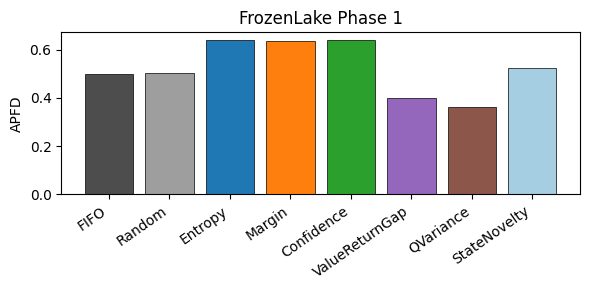

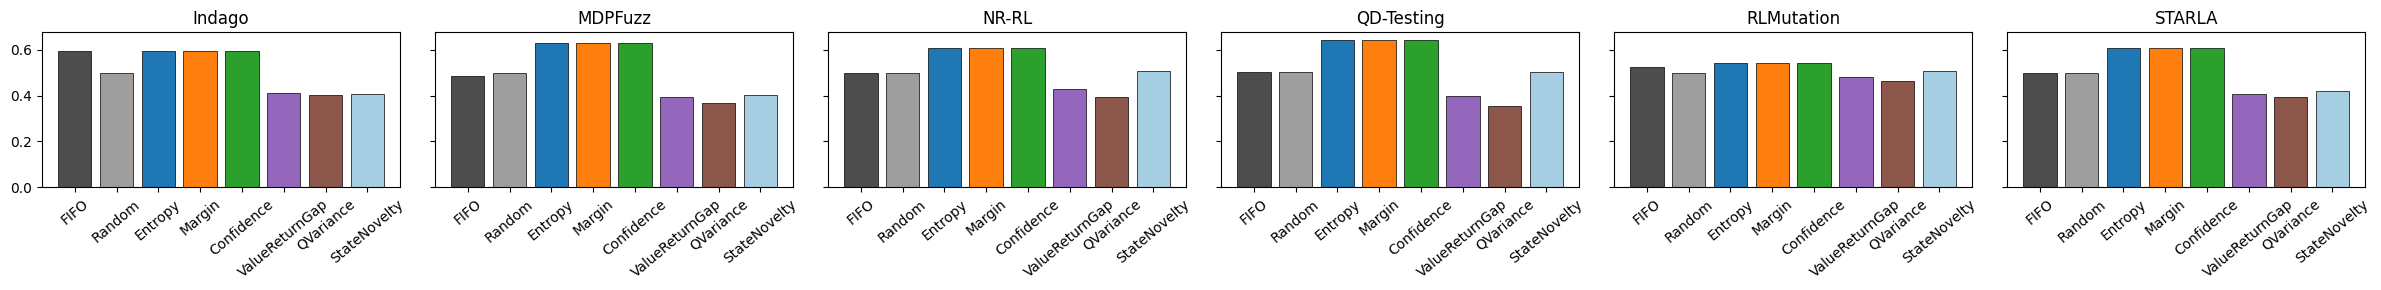

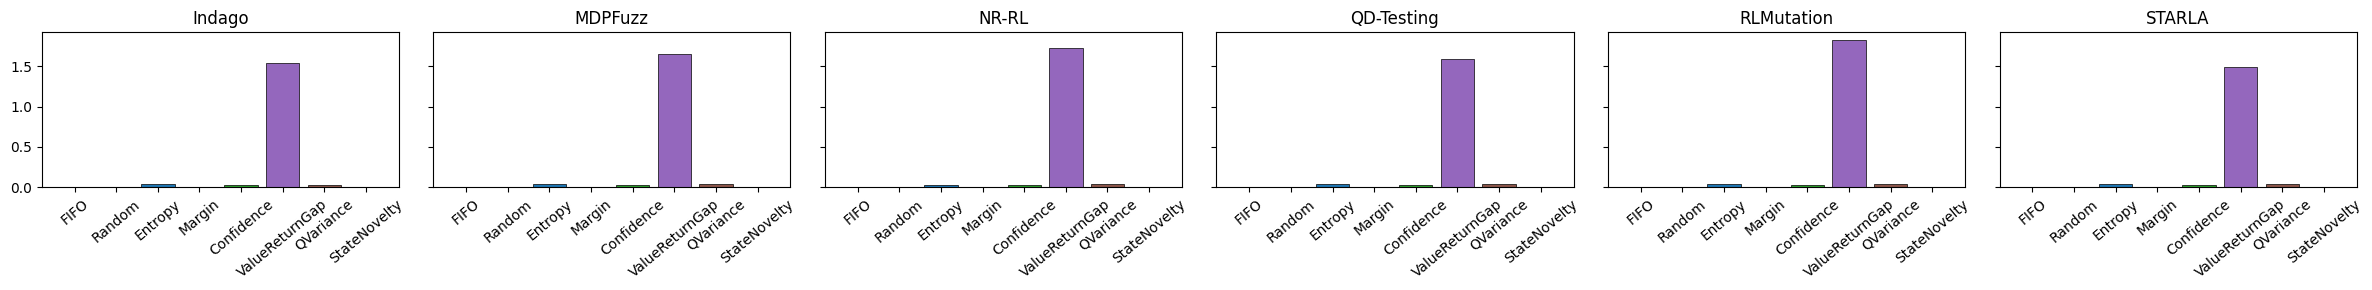


Tables : /content/drive/MyDrive/mbrl-testing-frameworks-empirical-study/results/frozenlake/tables
Figures: /content/drive/MyDrive/mbrl-testing-frameworks-empirical-study/results/frozenlake/figs


In [30]:
# =============================================================================
# MAIN
# =============================================================================

def main():

    print("=" * 70)
    print("FROZENLAKE TCP REPLICATION")
    print("=" * 70)

    print("\nRunning Phase 1...")
    phase1_results = run_phase1()

    phase1_agg = summarize_phase1(
        phase1_results
    )

    phase1_stats = phase1_statistics(
        phase1_results
    )

    print("\nRunning Phase 2...")
    phase2_results = run_phase2()

    phase2_agg = summarize_phase2(
        phase2_results
    )

    phase2_stats = phase2_statistics(
        phase2_results
    )

    print("\nGenerating plots...")

    plot_phase1_apfd(
        phase1_agg
    )

    plot_phase2_apfd(
        phase2_agg
    )

    plot_phase2_overhead(
        phase2_agg
    )

    print(
        f"\nTables : {TABLES_DIR}"
    )

    print(
        f"Figures: {FIGS_DIR}"
    )

    return {
        "phase1_results": phase1_results,
        "phase2_results": phase2_results,
        "phase1_statistics": phase1_stats,
        "phase2_statistics": phase2_stats,
    }


if __name__ == "__main__":

    outputs = main()